<a href="https://colab.research.google.com/github/xEzIxX/AI-Class/blob/master/week11/TSLA_RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
# 필요한 라이브러리 모듈을 포함

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [48]:
# TSLA 데이터 불러오기
tesla = pd.read_csv("/content/drive/MyDrive/TSLA.csv")

openValues = tesla[['Open']]
closeValues = tesla[['Close']]

In [50]:
from sklearn.preprocessing import MinMaxScaler

openScaler = MinMaxScaler(feature_range=(0, 1))
closeScaler = MinMaxScaler(feature_range=(0, 1))

scaledOpen = openScaler.fit_transform(openValues)
scaledClose = closeScaler.fit_transform(closeValues)

In [59]:
# 훈련 데이터와 테스트 데이터의 분리

TEST_SIZE = 200

train_open = scaledOpen[:-TEST_SIZE]
train_close = scaledClose[:-TEST_SIZE]

test_open = scaledOpen[-TEST_SIZE:]
test_close = scaledClose[-TEST_SIZE:]

In [61]:
# 순차 훈련 데이터를 생성
# window=3으로 설정하였다, 따라서 3일치 Open 값을 보고 다음 날 Close 값을 예측!

def make_sample(open_data, close_data, window):
    train = []
    target = []

    for i in range(len(open_data) - window):
        train.append(open_data[i:i + window])
        target.append(close_data[i + window])

    return np.array(train), np.array(target)


X_train, y_train = make_sample(train_open, train_close, 3)

print(X_train.shape)
print(y_train.shape)

(2753, 3, 1)
(2753, 1)


In [62]:
# SimpleRNN 구축하기

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

model = Sequential()

model.add(SimpleRNN(
    16,
    input_shape=(X_train.shape[1], 1),
    activation='tanh'
))

In [63]:
# 모델 학습

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16
)

Epoch 1/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0065
Epoch 2/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.4332e-04
Epoch 3/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.0763e-04
Epoch 4/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.8648e-04
Epoch 5/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7655e-04
Epoch 6/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7433e-04
Epoch 7/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6887e-04
Epoch 8/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6530e-04
Epoch 9/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6337e-04
Epoch 10/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.6803e-04
Epoch 11/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6429e-04
Epoch 12/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.5719e-04
Epoch 13/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5055e-04
Epoch 14/100
173/173 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.

In [65]:
# 테스트셋을 이용하여 Close 예측

X_test, y_test = make_sample(test_open, test_close, 3)

pred = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


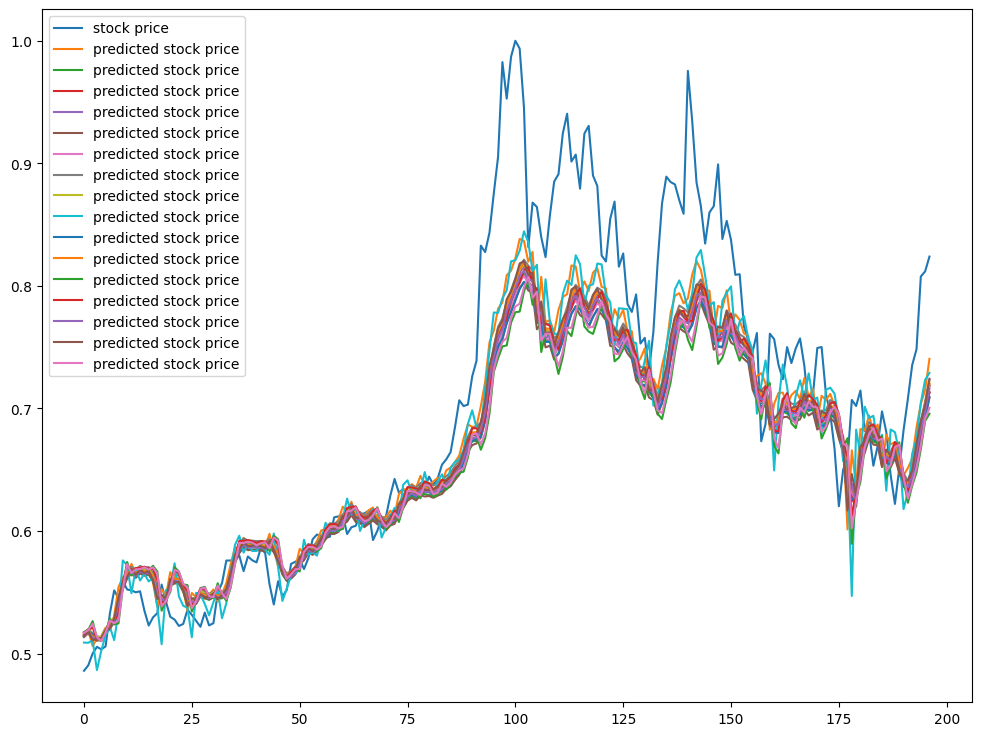

In [66]:
# 그래프 그리기

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 9))
plt.plot(y_test, label='stock price')
plt.plot(pred, label='predicted stock price')
plt.legend()
plt.show()